In [1]:
from typing import Dict,TypedDict,List
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
   num1: int
   num2: int
   operation: str
   result: int

In [ ]:
def adder(state: AgentState) -> AgentState:
    """Adds num1 and num2 and stores the result in the state."""
  
    state['result'] = state['num1'] + state['num2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtracts num2 from num1 and stores the result in the state."""
  
    state['result'] = state['num1'] - state['num2']
    return state

# return edge
def decide_next_node(state: AgentState) -> str:
    """Decides the next node based on the operation specified in the state."""
  
    if state['operation'] == '+':
        return 'addition'      #edge name
    elif state['operation'] == '-':
        return 'subtraction'
    else:
        raise ValueError(f"Unsupported operation: {state['operation']}")

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)  # pass through function:state is not updtated

graph.add_edge(START ,"router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {   #path map
        "addition": "add_node",
        "subtraction": "subtract_node"
    }
    )
graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)


app=graph.compile()

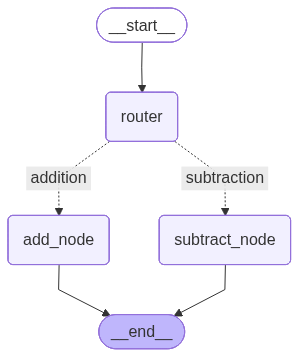

In [8]:
from  IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state_1 = AgentState(num1=10, num2=5, operation='+')
print(app.invoke(initial_state_1))  # Should print the state with result 15


{'num1': 10, 'num2': 5, 'operation': '+', 'result': 15}
